## Неделя 3. Понедельник

### Кластеризация и понижение размерности

### Кластеризация табличных данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# !pip install umap-learn
from umap import UMAP
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import sklearn
sklearn.set_config(transform_output='pandas')


pd.options.display.float_format ='{:,.3f}'.format

Загрузим датасет, содержащий описания пингвинов. 

In [2]:
url = "https://github.com/allisonhorst/palmerpenguins/raw/5b5891f01b52ae26ad8cb9755ec93672f49328a8/data/penguins_size.csv"

penguins = pd.read_csv(url)
penguins.head()

,species_short,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100,18.700,181.000,"3,750.000",MALE
1,Adelie,Torgersen,39.500,17.400,186.000,"3,800.000",FEMALE
2,Adelie,Torgersen,40.300,18.000,195.000,"3,250.000",FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.700,19.300,193.000,"3,450.000",FEMALE


<img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/culmen_depth.png" width=460 />

In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species_short      344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Заполним пропуски средними значениями.

In [4]:
for col in penguins.columns:
    if penguins[col].dtype in ['int64', 'float64'] and penguins[col].isna().sum() != 0:
        penguins[col].fillna(penguins[col].mean(), inplace=True)

/var/folders/ms/2vkb1zvd31g8wvmkgtbs0c0w0000gn/T/ipykernel_24525/1862219043.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins[col].fillna(penguins[col].mean(), inplace=True)


Сделаем выборку только по числовым признакам и запишем в отдельную переменную вид пингвина: 

In [5]:
le = LabelEncoder()
species  = le.fit_transform(penguins['species_short']) # Просто закодируем виды пингвинов, будет нужно для подсчета внешних метрик

numeric_features = penguins.select_dtypes(include=['float', int]) # Кластеризацию прводим на числовых признаках

Визуализируем попарные диаграммы числовых признаков.

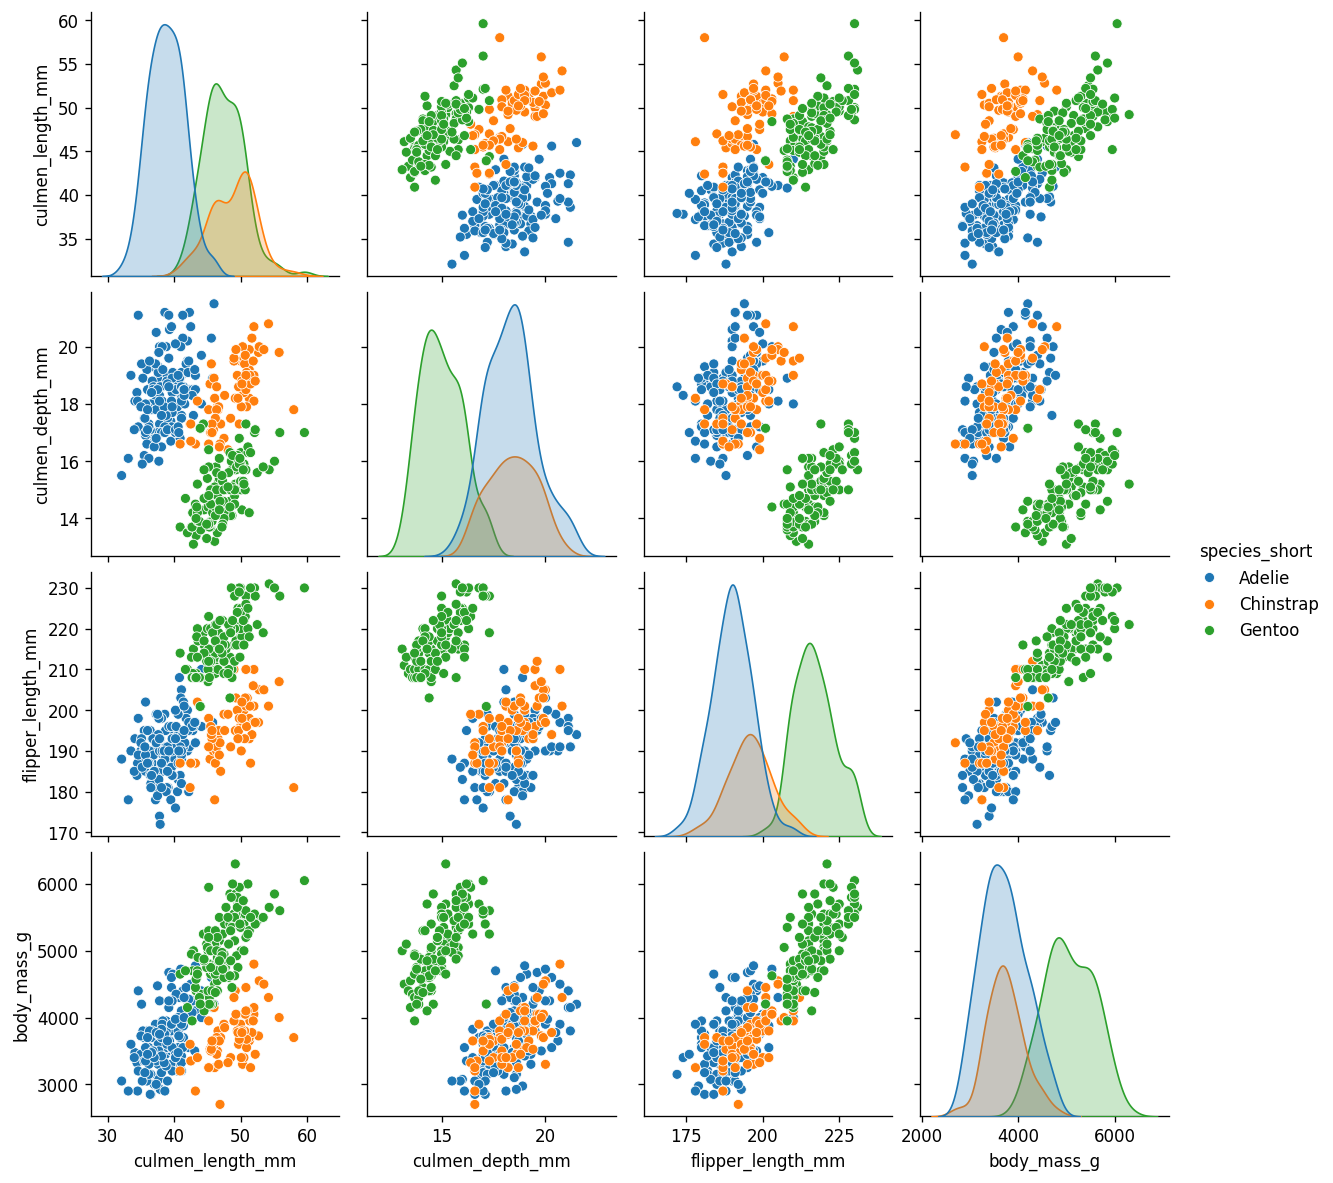

In [6]:
sns.pairplot(penguins, 
             x_vars=list(penguins.columns[2:-1]), 
             y_vars=list(penguins.columns[2:-1]), 
             hue='species_short')

Стандартизируем данные для применения кластеризации. 

In [8]:
X = StandardScaler().fit_transform(numeric_features)

In [9]:
X

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,-0.887,0.788,-1.422,-0.566
1,-0.813,0.127,-1.065,-0.503
2,-0.666,0.432,-0.423,-1.192
3,-0.000,0.000,0.000,0.000
4,-1.329,1.093,-0.565,-0.942
...,...,...,...,...
339,-0.000,0.000,0.000,0.000
340,0.529,-1.450,1.006,0.812
341,1.192,-0.738,1.506,1.939
342,0.235,-1.196,0.792,1.250


Создаем 3 объекта для моделей понижения размерности: метода главных компонент, TSNE, UMAP. Указываем, что хотим возвращать два измерения. Параметры TSNE и UMAP нужно подбирать. 

In [10]:
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30)
ump = umap.UMAP(n_components=2, n_neighbors=100)

Трансформируем данные:

In [11]:
X_pca = pca.fit_transform(X)
X_tsne = tsne.fit_transform(X)
X_umap = ump.fit_transform(X)

In [12]:
X_pca

,pca0,pca1
0,-1.849,0.048
1,-1.311,-0.430
2,-1.373,-0.155
3,0.000,0.000
4,-1.884,-0.002
...,...,...
339,-0.000,0.000
340,1.846,-0.770
341,2.769,0.290
342,1.727,-0.706


Визуализируем результаты:

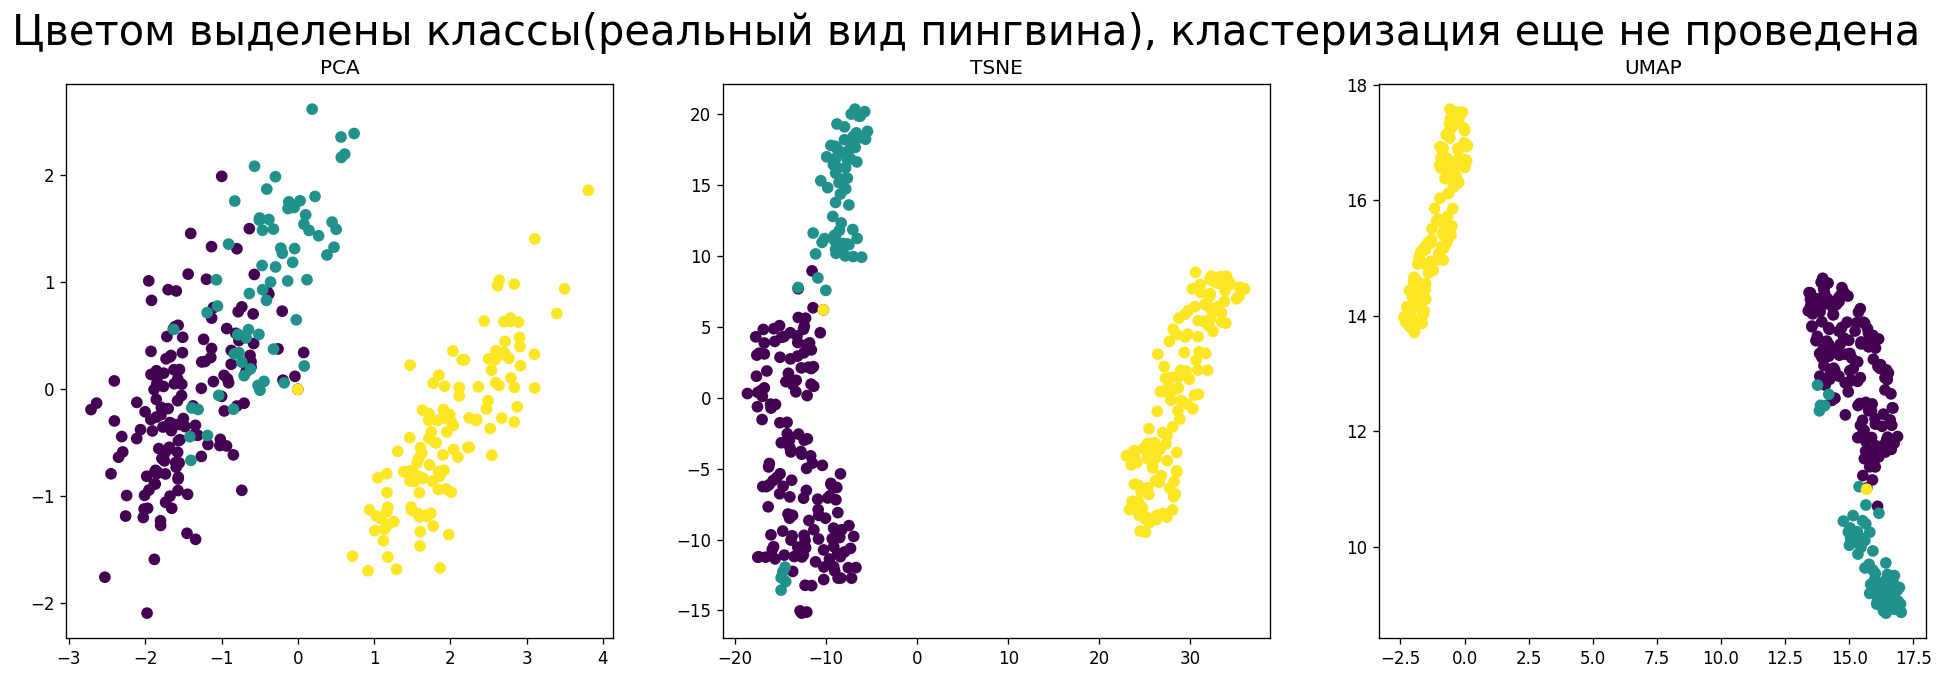

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

colors = [sns.color_palette()[x] for x in penguins.species_short.map({"Adelie":0, "Chinstrap":1, "Gentoo":2})]


plt.suptitle('Цветом выделены классы(реальный вид пингвина), кластеризация еще не проведена', fontsize=25)
ax1.scatter(X_pca.iloc[:, 0], X_pca.iloc[:, 1], c=species)
ax2.scatter(X_tsne.iloc[:, 0], X_tsne.iloc[:, 1], c=species)
ax3.scatter(X_umap[:, 0], X_umap[:, 1], c=species)

ax1.set_title('PCA')
ax2.set_title('TSNE')
ax3.set_title('UMAP')

plt.show()


Попробуем кластеризовать эти данные.

In [14]:
from sklearn.metrics import homogeneity_score, completeness_score, silhouette_score, rand_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

Попробуем три разных метода, которые рассматривали на лекции. 

In [15]:
km = KMeans(3)
ap = AgglomerativeClustering()
dbs = DBSCAN(eps=1.8, min_samples=4)

km.fit(X_tsne)
ap.fit(X_tsne)
dbs.fit(X_tsne)

DBSCAN(eps=1.8, min_samples=4)

После обучения объекта в нем появляется атрибут `labels_`, в котором хранятся метки __кластеров__. Визуализируем результаты разных подходов к кластеризации с разными подходами к понижению размерности. 

In [16]:
X = {
    'pca'  : X_pca,
    'tsne' : X_tsne,
    'umap' : X_umap
}

models = {
    'KMeans' : KMeans(3),
    'AggCls' : AgglomerativeClustering(3),
    'DBSCAN' : DBSCAN(eps=1)
}

In [17]:
def plot_results(X: dict, models: dict):
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    for i in np.arange(3):
        for j in np.arange(3):
            X_ = list(X.values())[i]
            model = list(models.values())[j].fit(X_)
            colors = model.labels_
            sil_score = silhouette_score(X_, model.labels_)
#            
            ax[i, j].scatter(np.array(X_)[:, 0], np.array(X_)[:, 1], c=colors, marker='.', s=10)
            ax[i, j].set_title(f'{list(X.keys())[i]}/{list(models.keys())[j]}: sil_score={sil_score:.3f}')

Визуализируем разные модели кластеризации, примененные к разным результатам понижения размерности и распечатаем метрику силуэта. 

<Figure size 768x576 with 0 Axes>

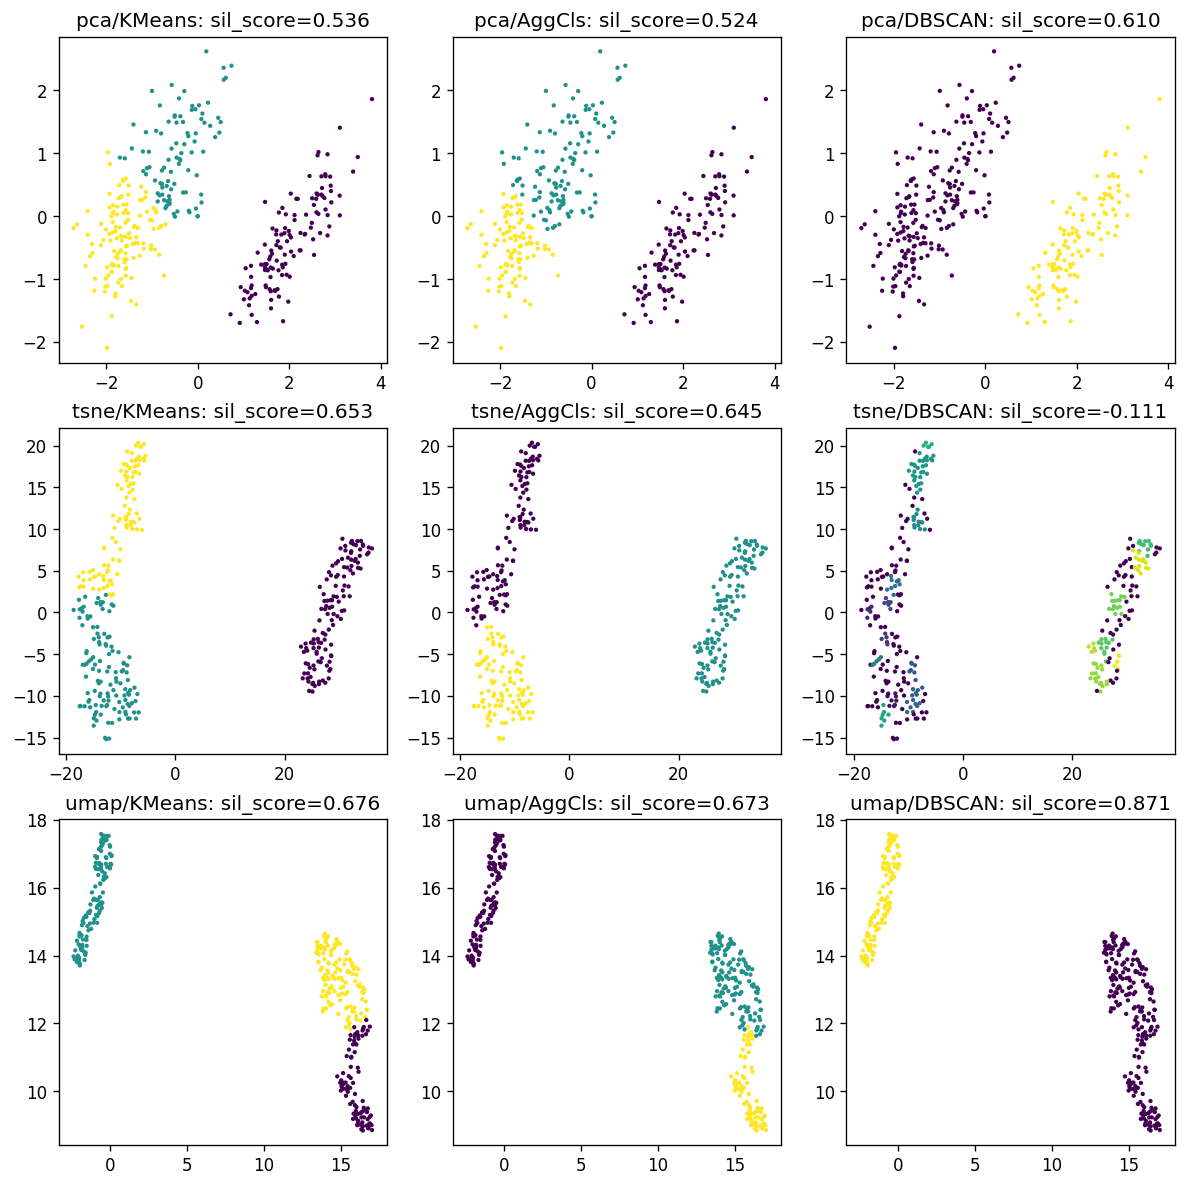

In [18]:
plt.suptitle('Цветом выделены кластеры')
plot_results(X, models)

**umap + DBSCAN дает высокий силует существенно выше, потому что он объединил два кластера, а не в три и у него не образовалось два близко лежащих кластера, которые ухудшают метрику силуета. Однако если посмотреть в контексте внешних метрик, сопоставляя кластеры и классы, это должно дать наоборот, отрицательный результат. Проверим это**  

Подсчитаем метрику `homogenity`, `completeness`: 

In [19]:
agg = AgglomerativeClustering(3)
dbs = DBSCAN(eps=1)

agg.fit(X_umap)
dbs.fit(X_umap)

DBSCAN(eps=1)

Помним, что у нас есть переменная `species`, в которой расположены настоящие метки видов пингвинов, а значит, мы можем применить и внешние метрики кластеризации. 

In [20]:
agglomerative_homogenity = homogeneity_score(species, agg.labels_)
agglomerative_completeness = completeness_score(species, agg.labels_)

agglomerative_homogenity, agglomerative_completeness

(0.8149394164011767, 0.7971906788195434)

* У агломеративной кластеризации, которая разбила на 3 кластера метрики очень высоки

In [21]:
dbscan_homogenity = homogeneity_score(species, dbs.labels_)
dbscan_completeness = completeness_score(species, dbs.labels_)

dbscan_homogenity, dbscan_completeness

(0.6053370373708333, 0.974068002306434)

* А вот у DBSCAN просела гомогенность, из-за возникновения $FP$, Это связано с тем, что в один кластер массово попали несколько классов

* Однозначное решение сложно дать, что лучше из этих двух вариантов, все зависит от задачи. Если нам необходимо было бы дать как можно более четкие кластеры, то их тут 2, так как два вида пингвинов очень похожи по параметрам друг на друга. Если же кластеры нужны в контексте именно видов пингвинов, то внешние метрики подсказывают, что лучше сделать 3 кластера 

### Понижение размерности примитивных изображений

В этом разделе рассмотрим простейший набор картинок: рукописные цифры размера 28х28.

In [23]:
from sklearn.datasets import load_digits

In [24]:
X_digits = load_digits().data
y = load_digits().target

In [31]:
X_digits[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

Визуализируем сэмплы из выборки. Каждое изображение - матрица 8х8, которую мы позже "выпрямим" и будем рассматривать как вектор.

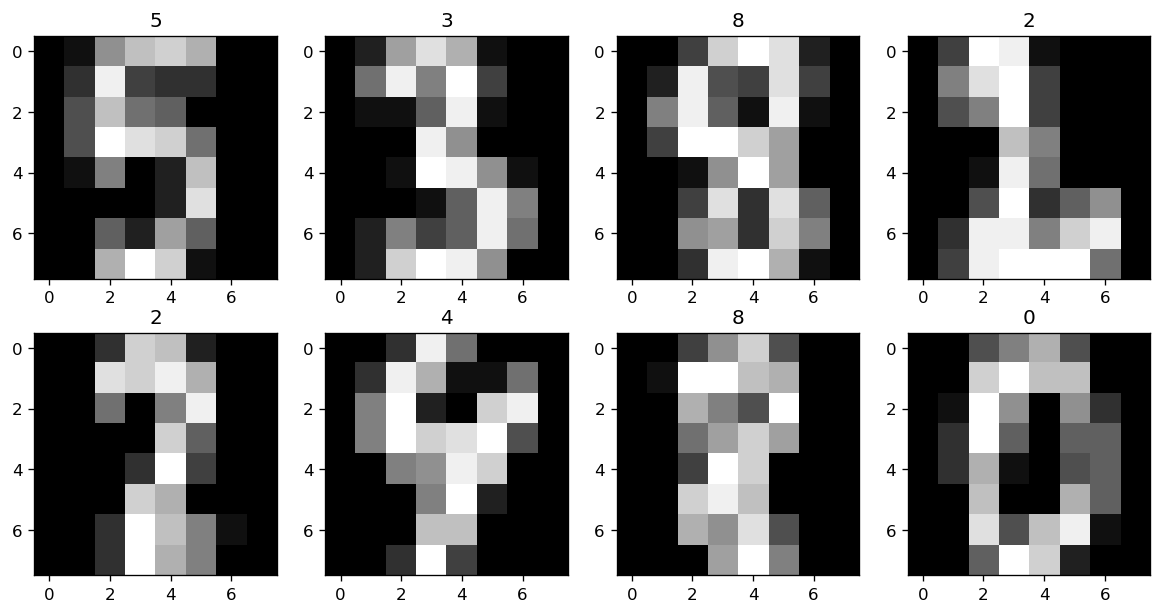

In [25]:
idx = np.random.randint(0, len(X_digits), size=8)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
ax = ax.flatten()
for i, pos in zip(idx, np.arange(8)):
    ax[pos].imshow(X_digits[i].reshape(8, 8), 'gray')
    ax[pos].set_title(f'{y[i]}')

Стандартизируем все объекты. 

In [32]:
X_digits = StandardScaler().fit_transform(X_digits)

In [33]:
X_digits[0].shape

(64,)

In [34]:
from time import time

Применим те же способы понижения размерности. 

In [35]:
pca = PCA(2)
tsne = TSNE(2, perplexity=30, init='random')
ump = umap.UMAP(n_components=2, n_neighbors=10)

start_t = time()
X_pca = pca.fit_transform(X_digits)
end_t = time()
print(f'PCA time: {end_t - start_t}')

start_t = time()
X_tsne = tsne.fit_transform(X_digits)
end_t = time()
print(f'TSNE time: {end_t - start_t}')

start_t = time()
X_umap = ump.fit_transform(X_digits)
end_t = time()
print(f'UMAP time: {end_t - start_t}')

PCA time: 0.028779983520507812


/Users/anton/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


TSNE time: 4.460752964019775
UMAP time: 3.005782127380371


А теперь попробуем визуализировать результат. 

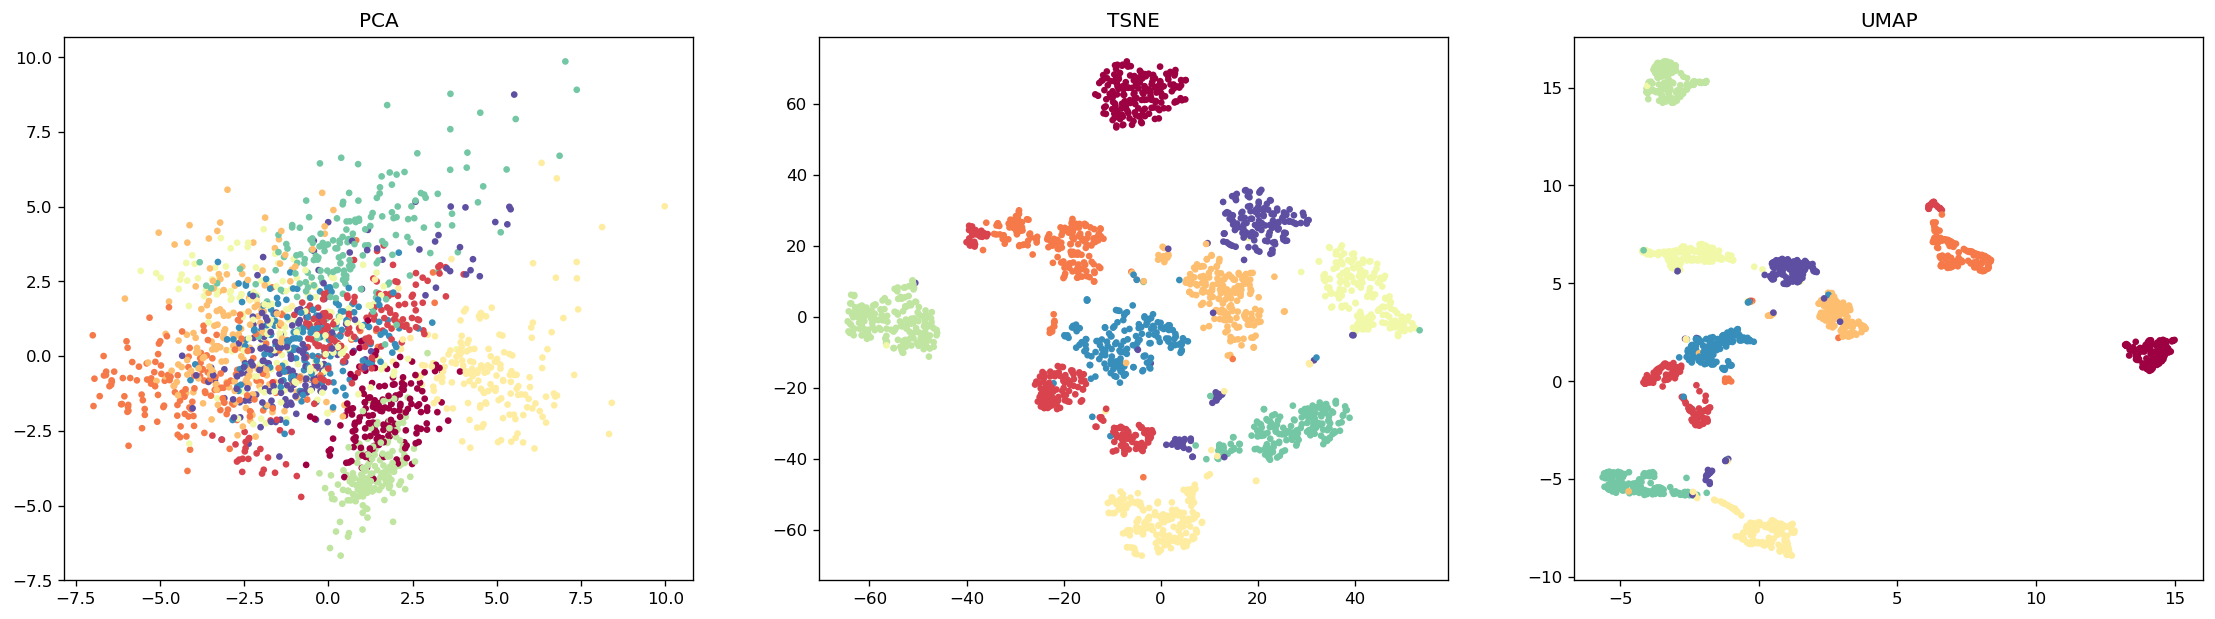

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(23, 6))

cm = 'Spectral'

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=cm, marker='.')
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap=cm, marker='.')
ax3.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap=cm, marker='.')

ax1.set_title('PCA')
ax2.set_title('TSNE')
ax3.set_title('UMAP');

Рассматорим UMAP - в качестве маркеров выберем классы цифр.

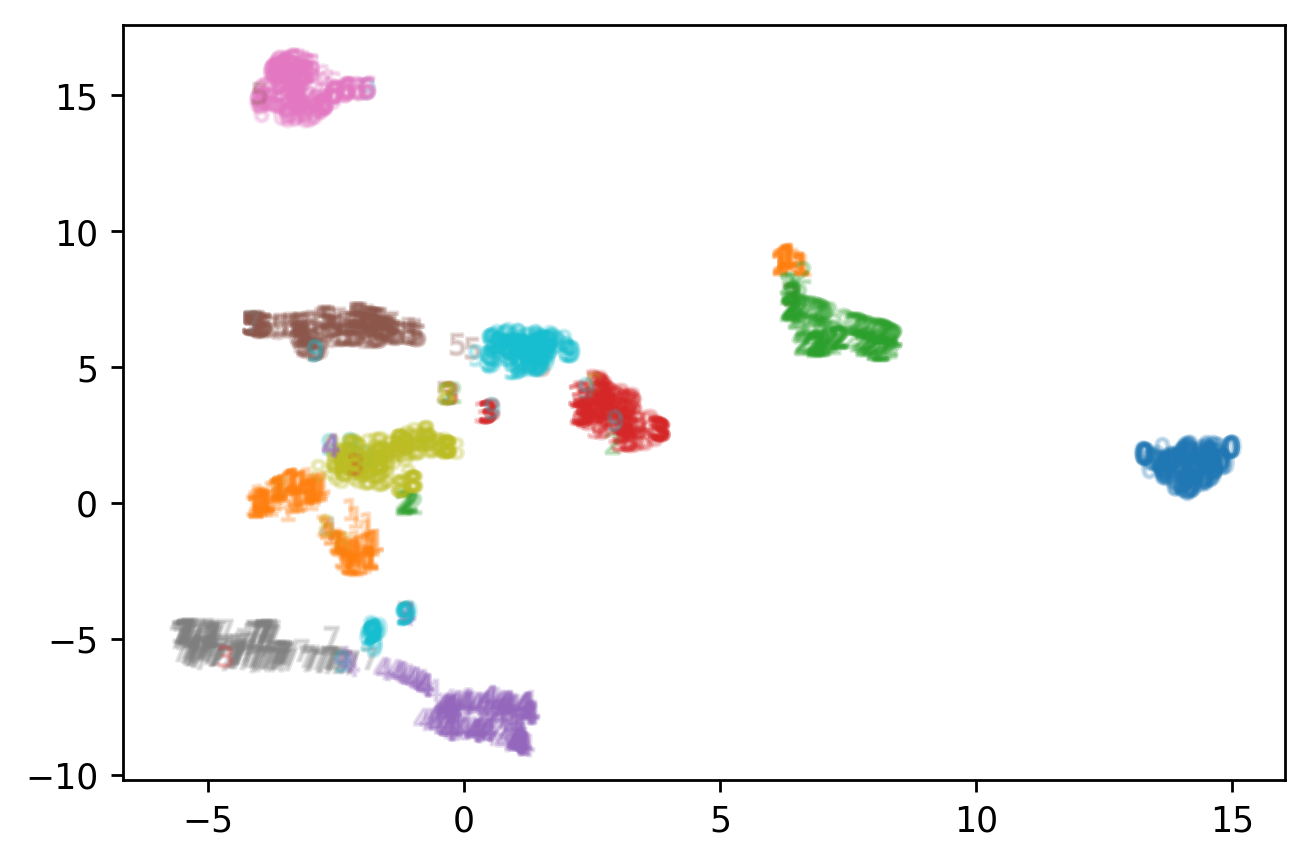

In [37]:
plt.rcParams['figure.dpi']=250
for point, mrkr in zip(X_umap, y):
    plt.scatter(*point, marker=f'${str(mrkr)}$', color=plt.cm.tab10(mrkr), alpha=.2);
plt.show()

Каждой цифре соответствует какая-то собственная область, хотя и не без ошибок. Теперь, вместо описания размерностью 64, мы можем использовать описание каждой цифры размерностью всего 2, что намного быстрее и удобнее. 

### Кластеризация изображений

Изображения тоже можно кластеризировать. Каждое изображение можно представить в виде тензора ВЫСОТА х ШИРИНА х 3. 3 - число каналов: красный, зеленый и синий. На разных изображениях разное соотношение этих цветов. Этим можно воспользоваться, чтобы кластеризировать изображения. 

Загрузим изображения и сразу решейпим их в вектора. 

In [14]:
import numpy as np
np.__version__

'1.21.5'

In [18]:
import os
import cv2
import umap

In [59]:
init_imgs = np.empty(())
flattened_imgs = np.empty((1, 30000))
for file in os.listdir('aux/pixabay/images/'):
    if not file.startswith('.'):
        
        img = plt.imread('aux/pixabay/images/' + file)
        if img.shape[-1] == 3:
            img = cv2.resize(img, (100, 100)) / 255
            img = img.reshape((1, 100*100*3))
            flattened_imgs = np.concatenate((flattened_imgs, img), axis=0)
        
        plt.show()

In [60]:
f_i = pd.DataFrame(flattened_imgs)

0      0
1      0
2      0
3      0
4      0
      ..
98     0
99     0
100    0
101    0
102    0
Length: 103, dtype: int64

In [54]:
f_i = f_i[f_i[0].notna()]

In [58]:
f_i[0].notna()

0      True
1      True
2      True
3      True
4      True
       ... 
98     True
99     True
100    True
101    True
102    True
Name: 0, Length: 103, dtype: bool

In [65]:
u = umap.UMAP(n_neighbors=5, n_components=2).fit_transform(flattened_imgs)

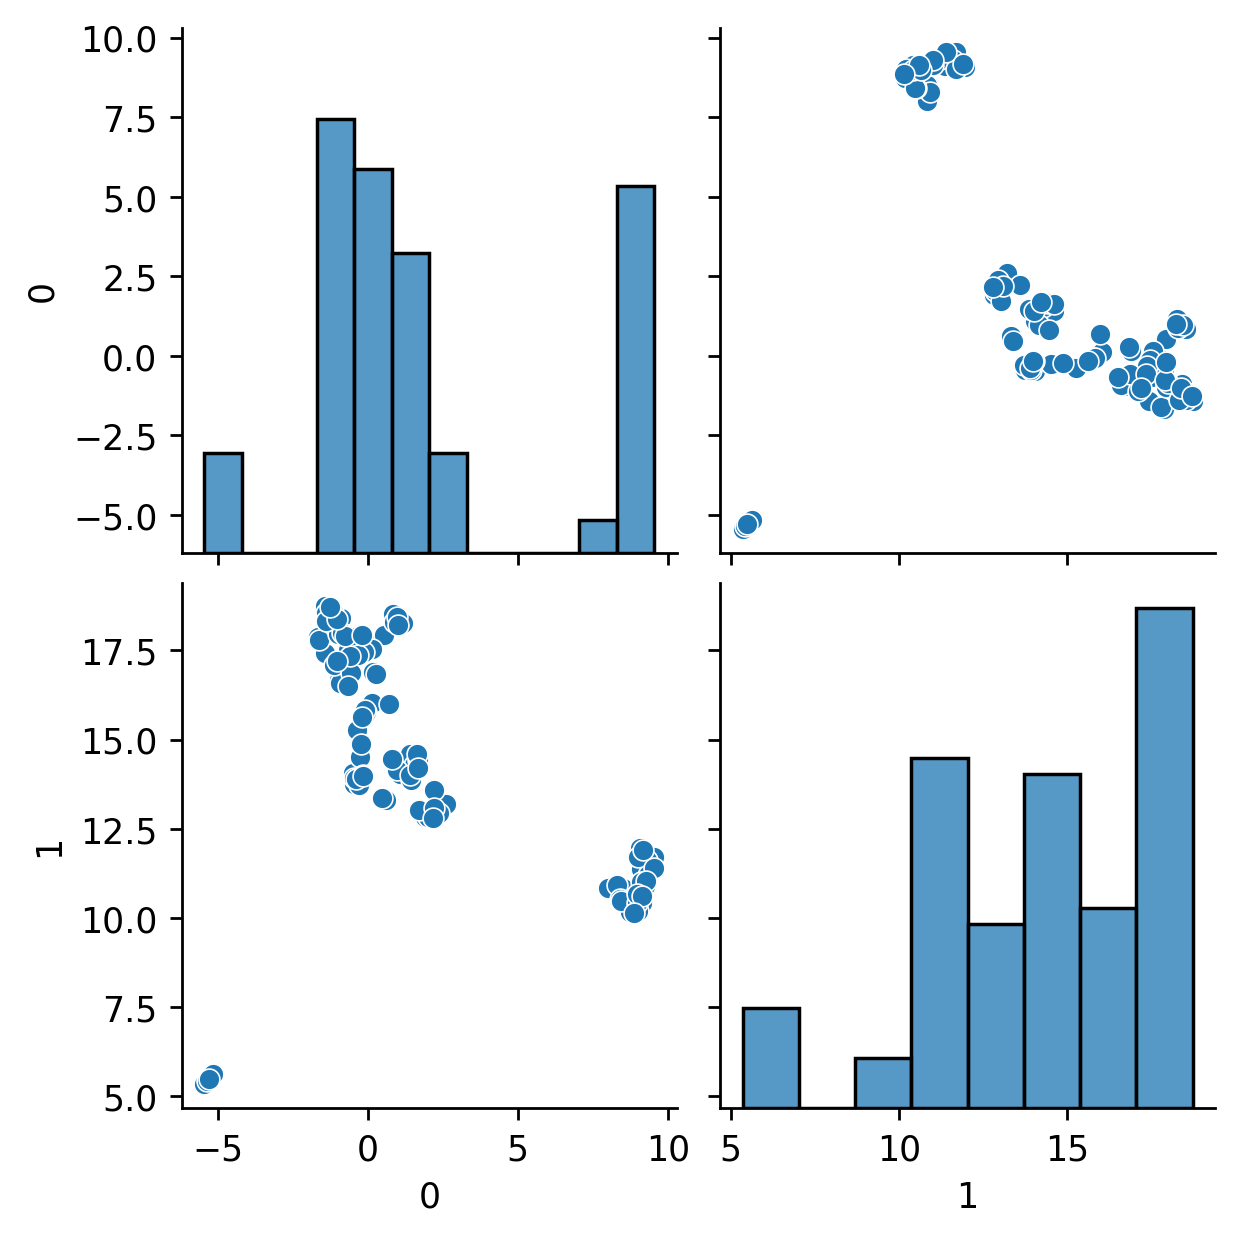

In [66]:
sns.pairplot(pd.DataFrame(u))

In [68]:
from sklearn.cluster import KMeans

In [69]:
km = KMeans(n_clusters=3)
km.fit(u)

KMeans(n_clusters=3)

In [70]:
def plot_images_from_clusters(cluster_id):
    n = len(flattened_imgs[km.labels_ == cluster_id]) // 5
    fig, ax = plt.subplots(n, 5, figsize=(16, 16))
    ax = ax.flatten()[:5*n]

    for pos, i in enumerate(flattened_imgs[km.labels_ == cluster_id][:5*n]):
        ax[pos].imshow(i.reshape((100, 100, 3)) / 1.)
    plt.show()

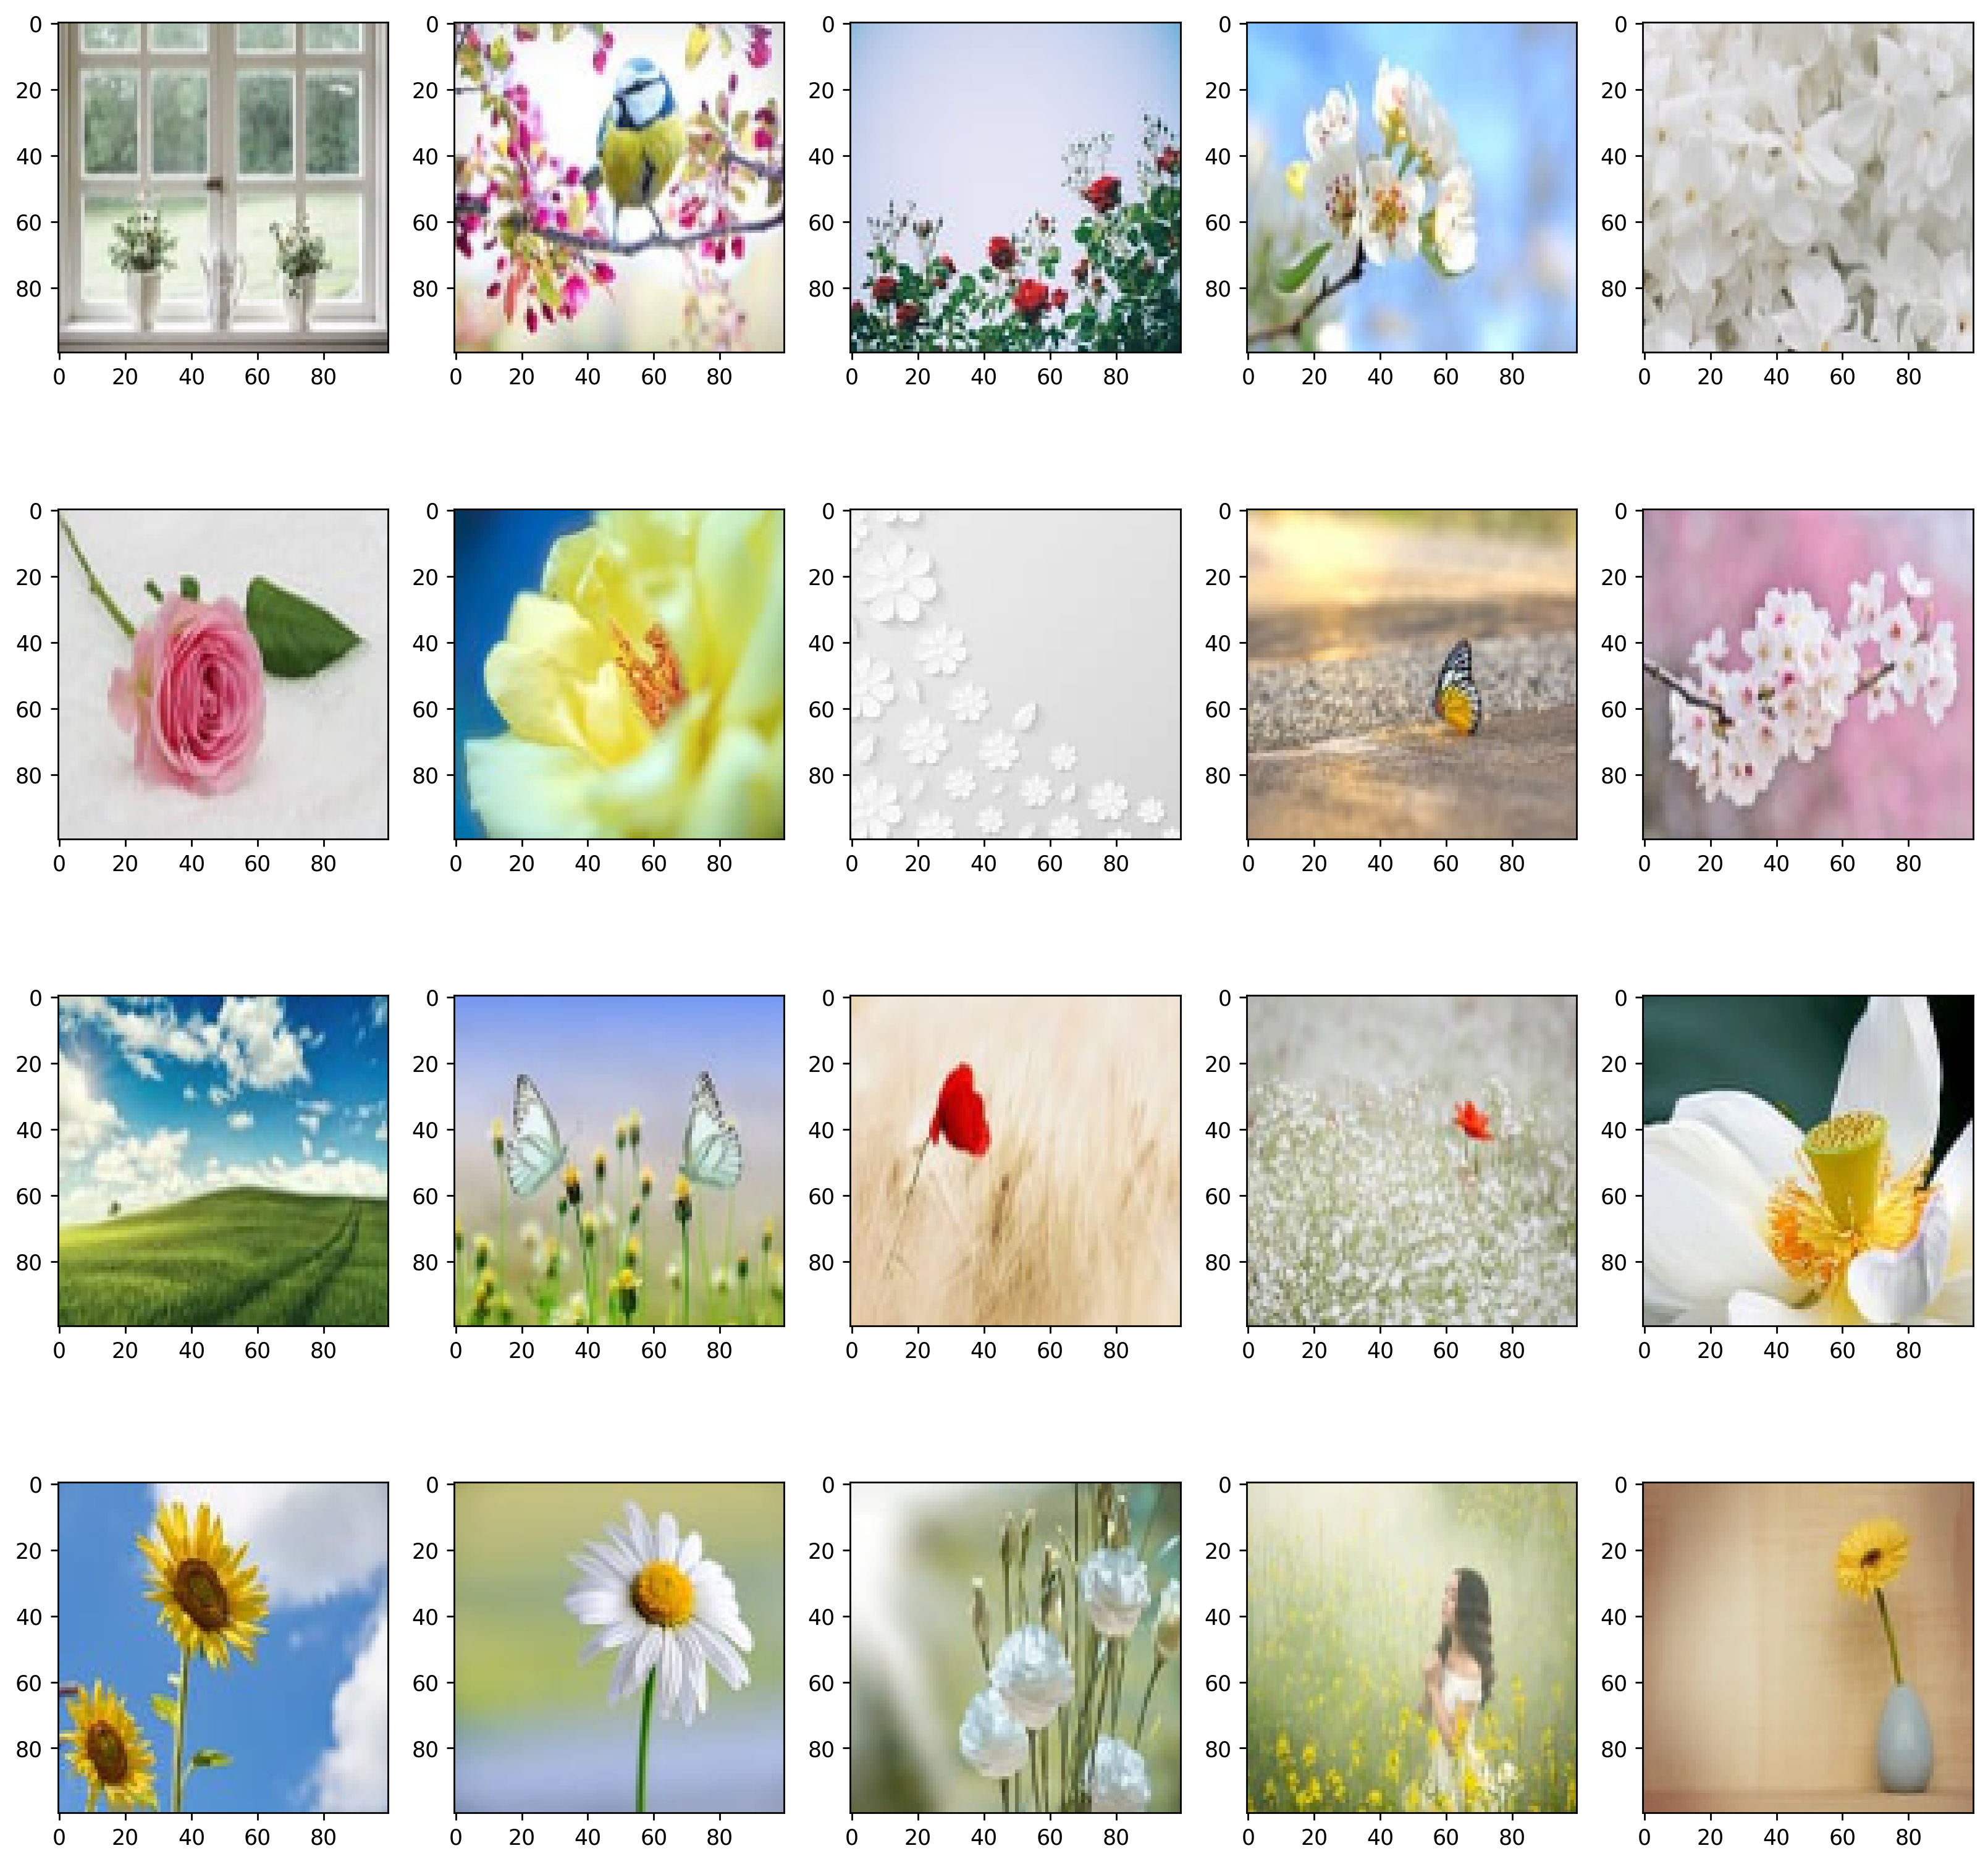

In [72]:
plot_images_from_clusters(1)

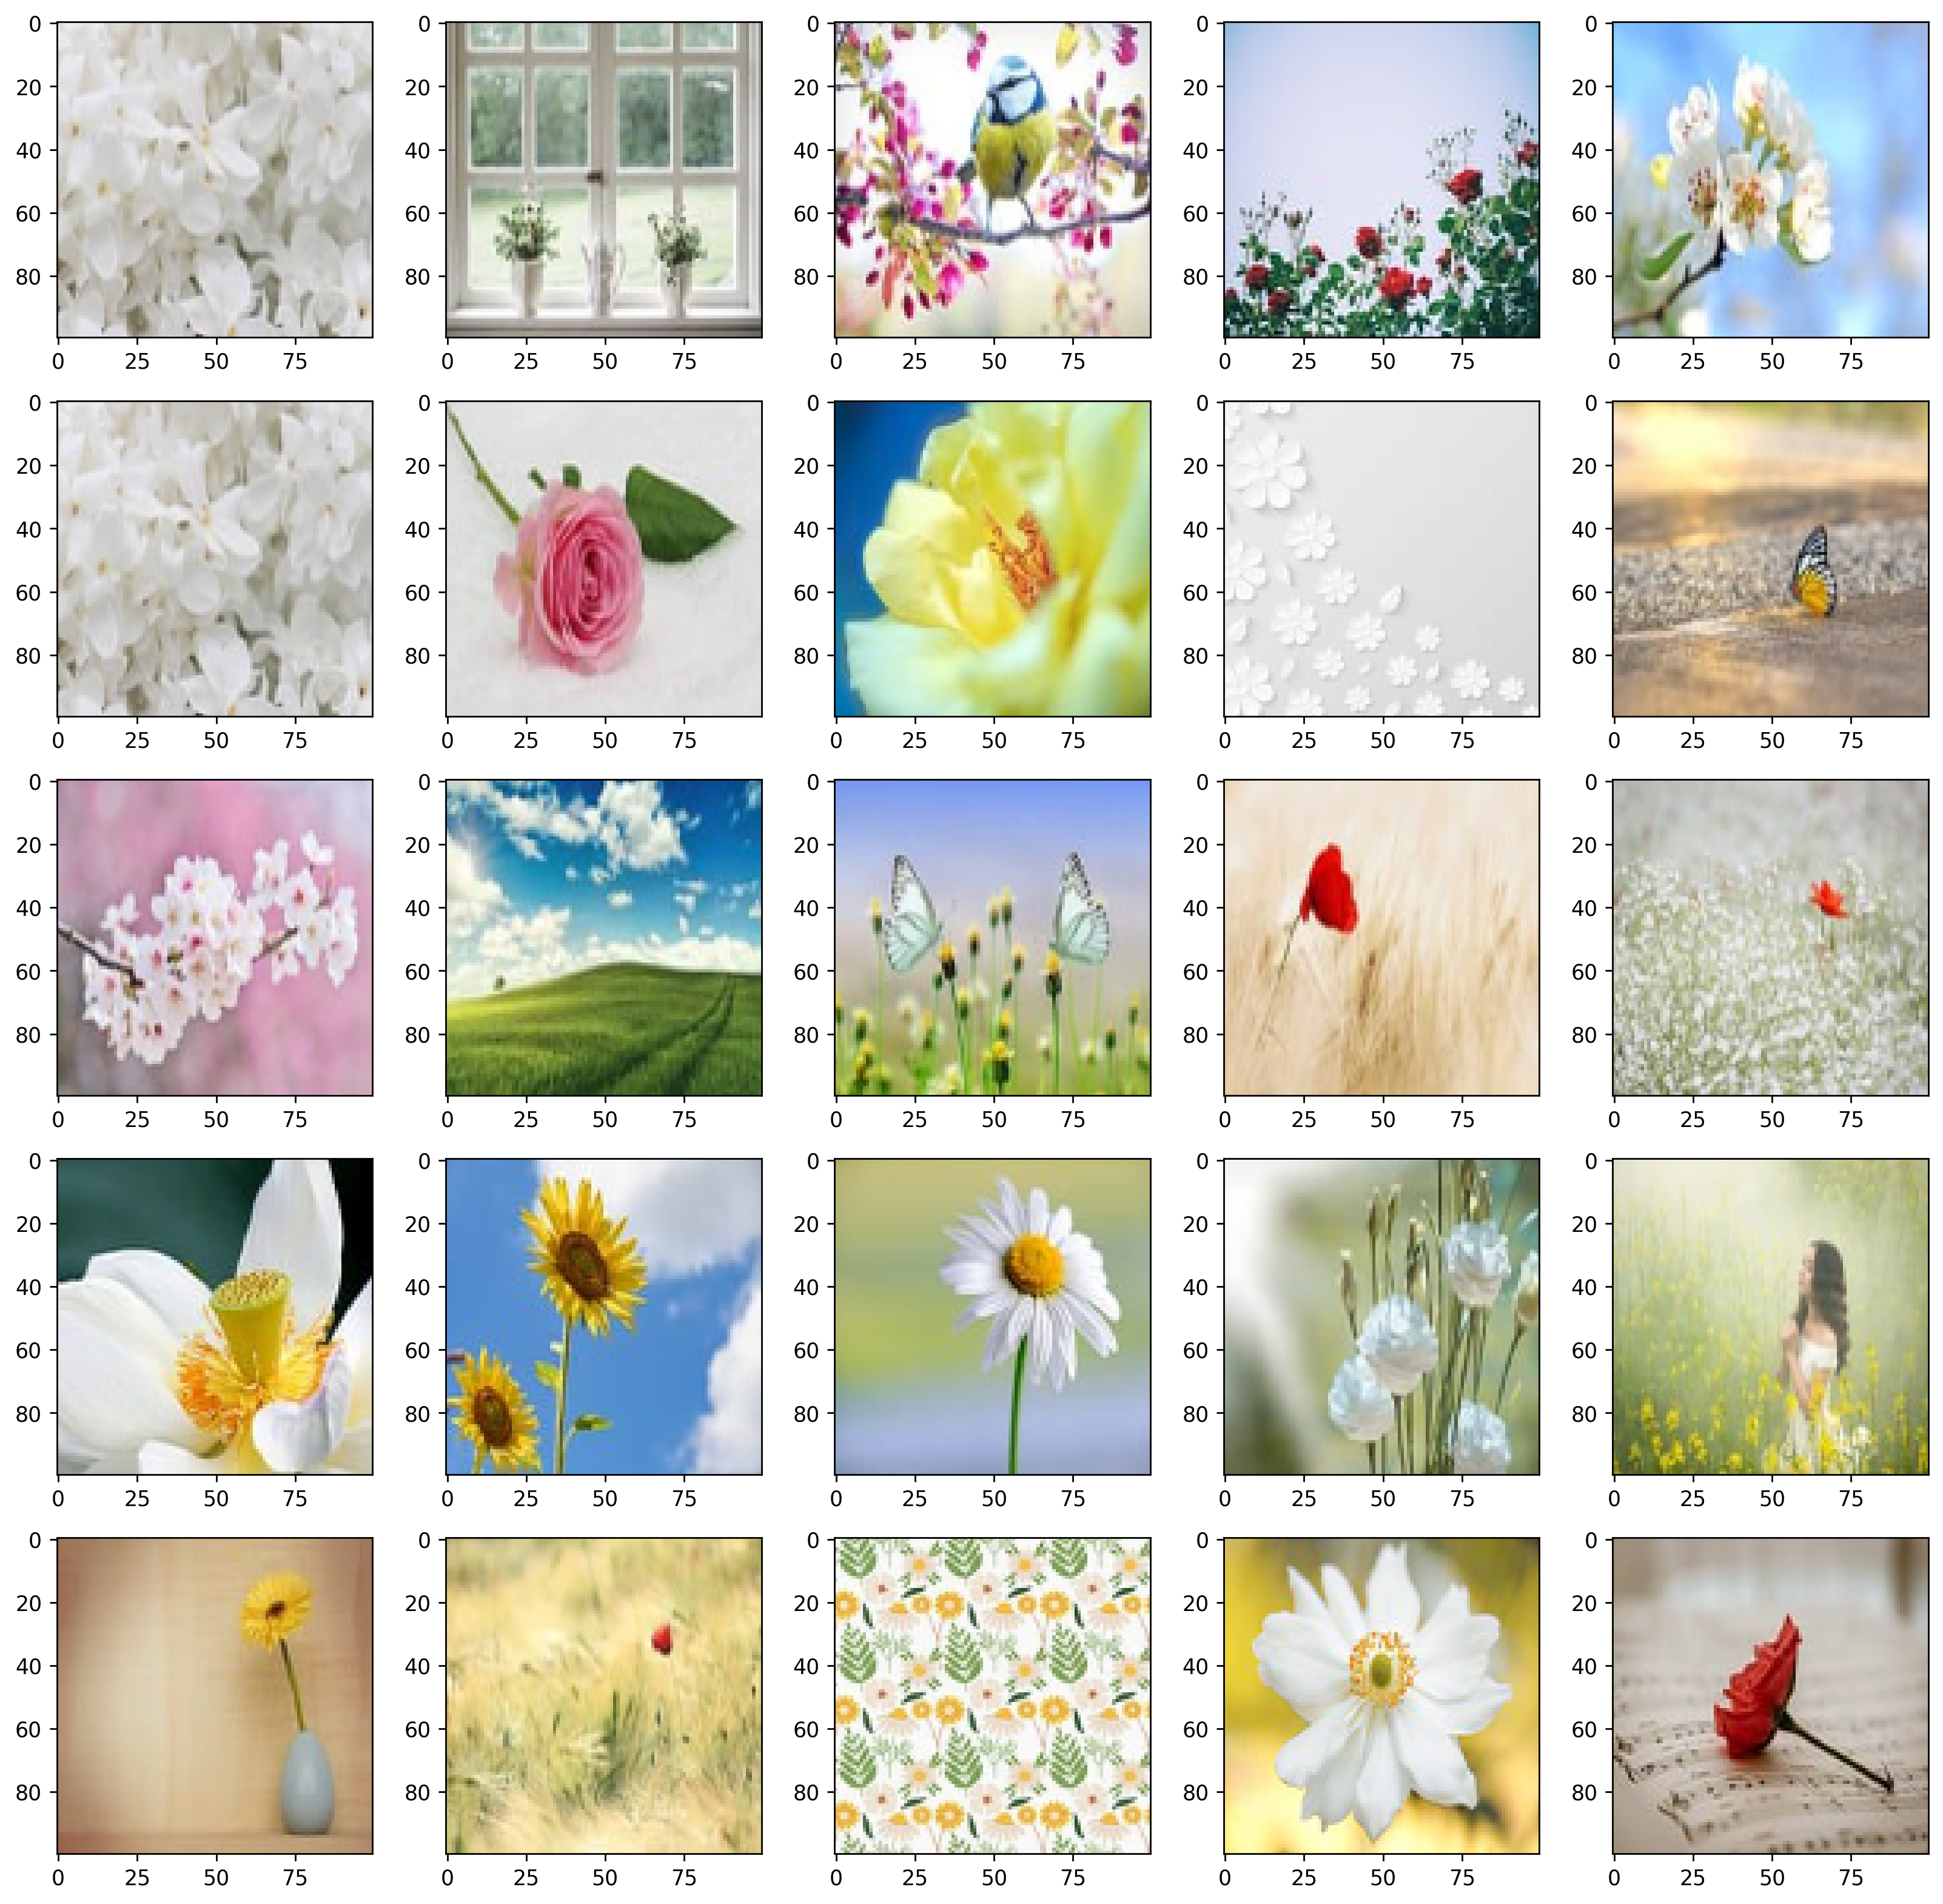

In [49]:
plot_images_from_clusters(1)

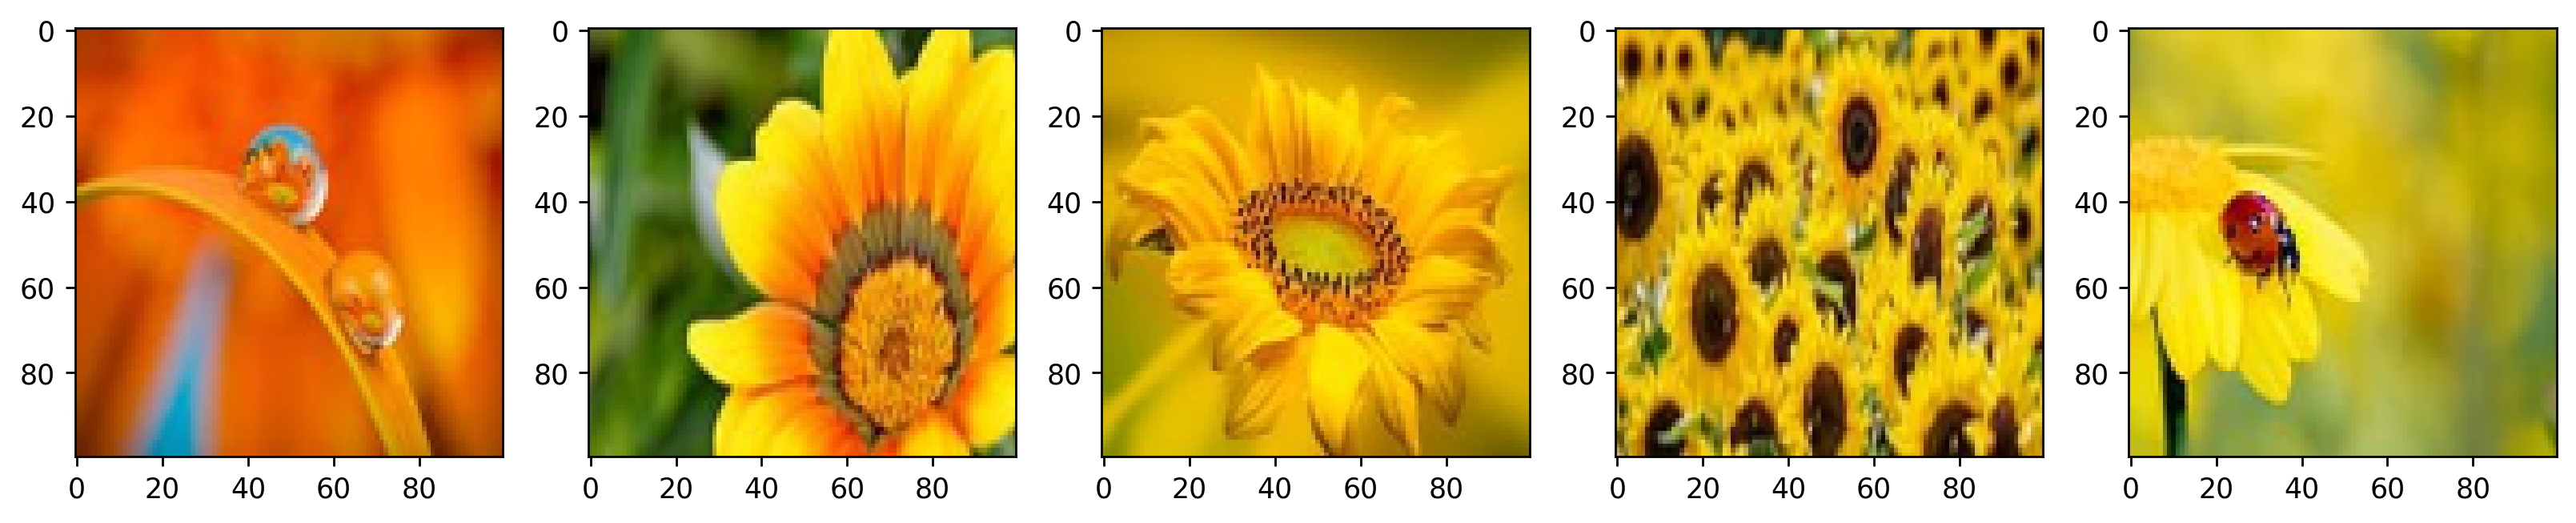

In [50]:
plot_images_from_clusters(2)

In [73]:
init_images = flattened_imgs.reshape((len(flattened_imgs), 100, 100, 3))

In [76]:
flag = 0
for clstr in np.unique(km.labels_):
    for ix_clr, name_clr in zip([0, 1, 2], ['r', 'g', 'b']):
        if ix_clr == 0:
            temp_df = pd.DataFrame({
                    'cl' : [clstr]*sum(km.labels_==clstr),
                    f'{name_clr}_mean' : init_images[:, :, :, ix_clr][km.labels_==clstr].mean(axis=1).mean(axis=1)
                    })
        else:
            temp_df[f'{name_clr}_mean'] = init_images[:, :, :, ix_clr][km.labels_==clstr].mean(axis=1).mean(axis=1)
    if flag:
        df = pd.concat([df, temp_df], )
    else:
        flag = 1
        df = temp_df

Теперь у нас есть матрица, в которой каждому изображению сответствует метка кластера, среднее значение красного, зеленого и синего цветов. 

In [77]:
df.head()

,cl,r_mean,g_mean,b_mean
0,0,2.247718e-314,2.247718e-314,2.247718e-314
1,0,3.071565e-01,4.891451e-01,4.450020e-01
2,0,2.353078e-01,4.675722e-01,5.338949e-01
3,0,3.674482e-01,2.482078e-02,3.768196e-02
4,0,2.992302e-01,1.445098e-01,9.966706e-02


In [78]:
import plotly.express as px

In [79]:
# нормируем так, чтобы соотношение цветов в сумме давало 1
df_normed = df.groupby('cl').mean().div(df.groupby('cl').mean().sum(axis=1), axis=0)

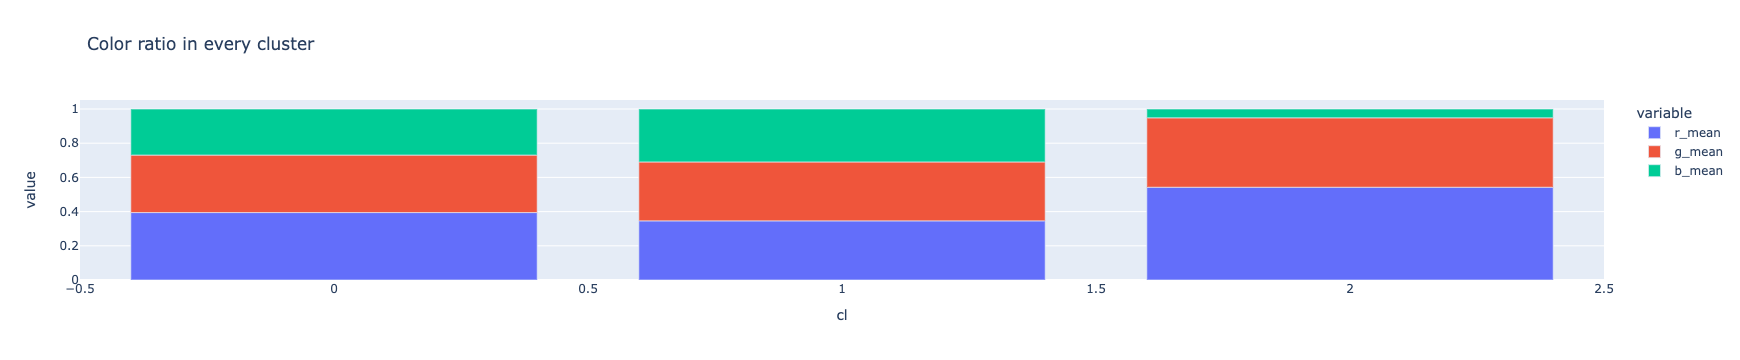

In [80]:
fig = px.bar(df_normed, title='Color ratio in every cluster')
fig.show()

In [81]:
def get_colors_dists(color):
    fig, ax = plt.subplots(4, 1, figsize=(14, 6))
    if color == 0:
        c = 'red'
    elif color == 1:
        c = 'green'
    elif color == 2:
        c = 'blue'
    ax[0].hist(init_images[:, :, :, color][km.labels_==0].ravel(), bins=20, color=c);
    ax[1].hist(init_images[:, :, :, color][km.labels_==1].ravel(), bins=20, color=c);
    ax[2].hist(init_images[:, :, :, color][km.labels_==2].ravel(), bins=20, color=c);
    ax[3].hist(init_images[:, :, :, color][km.labels_==3].ravel(), bins=20, color=c);

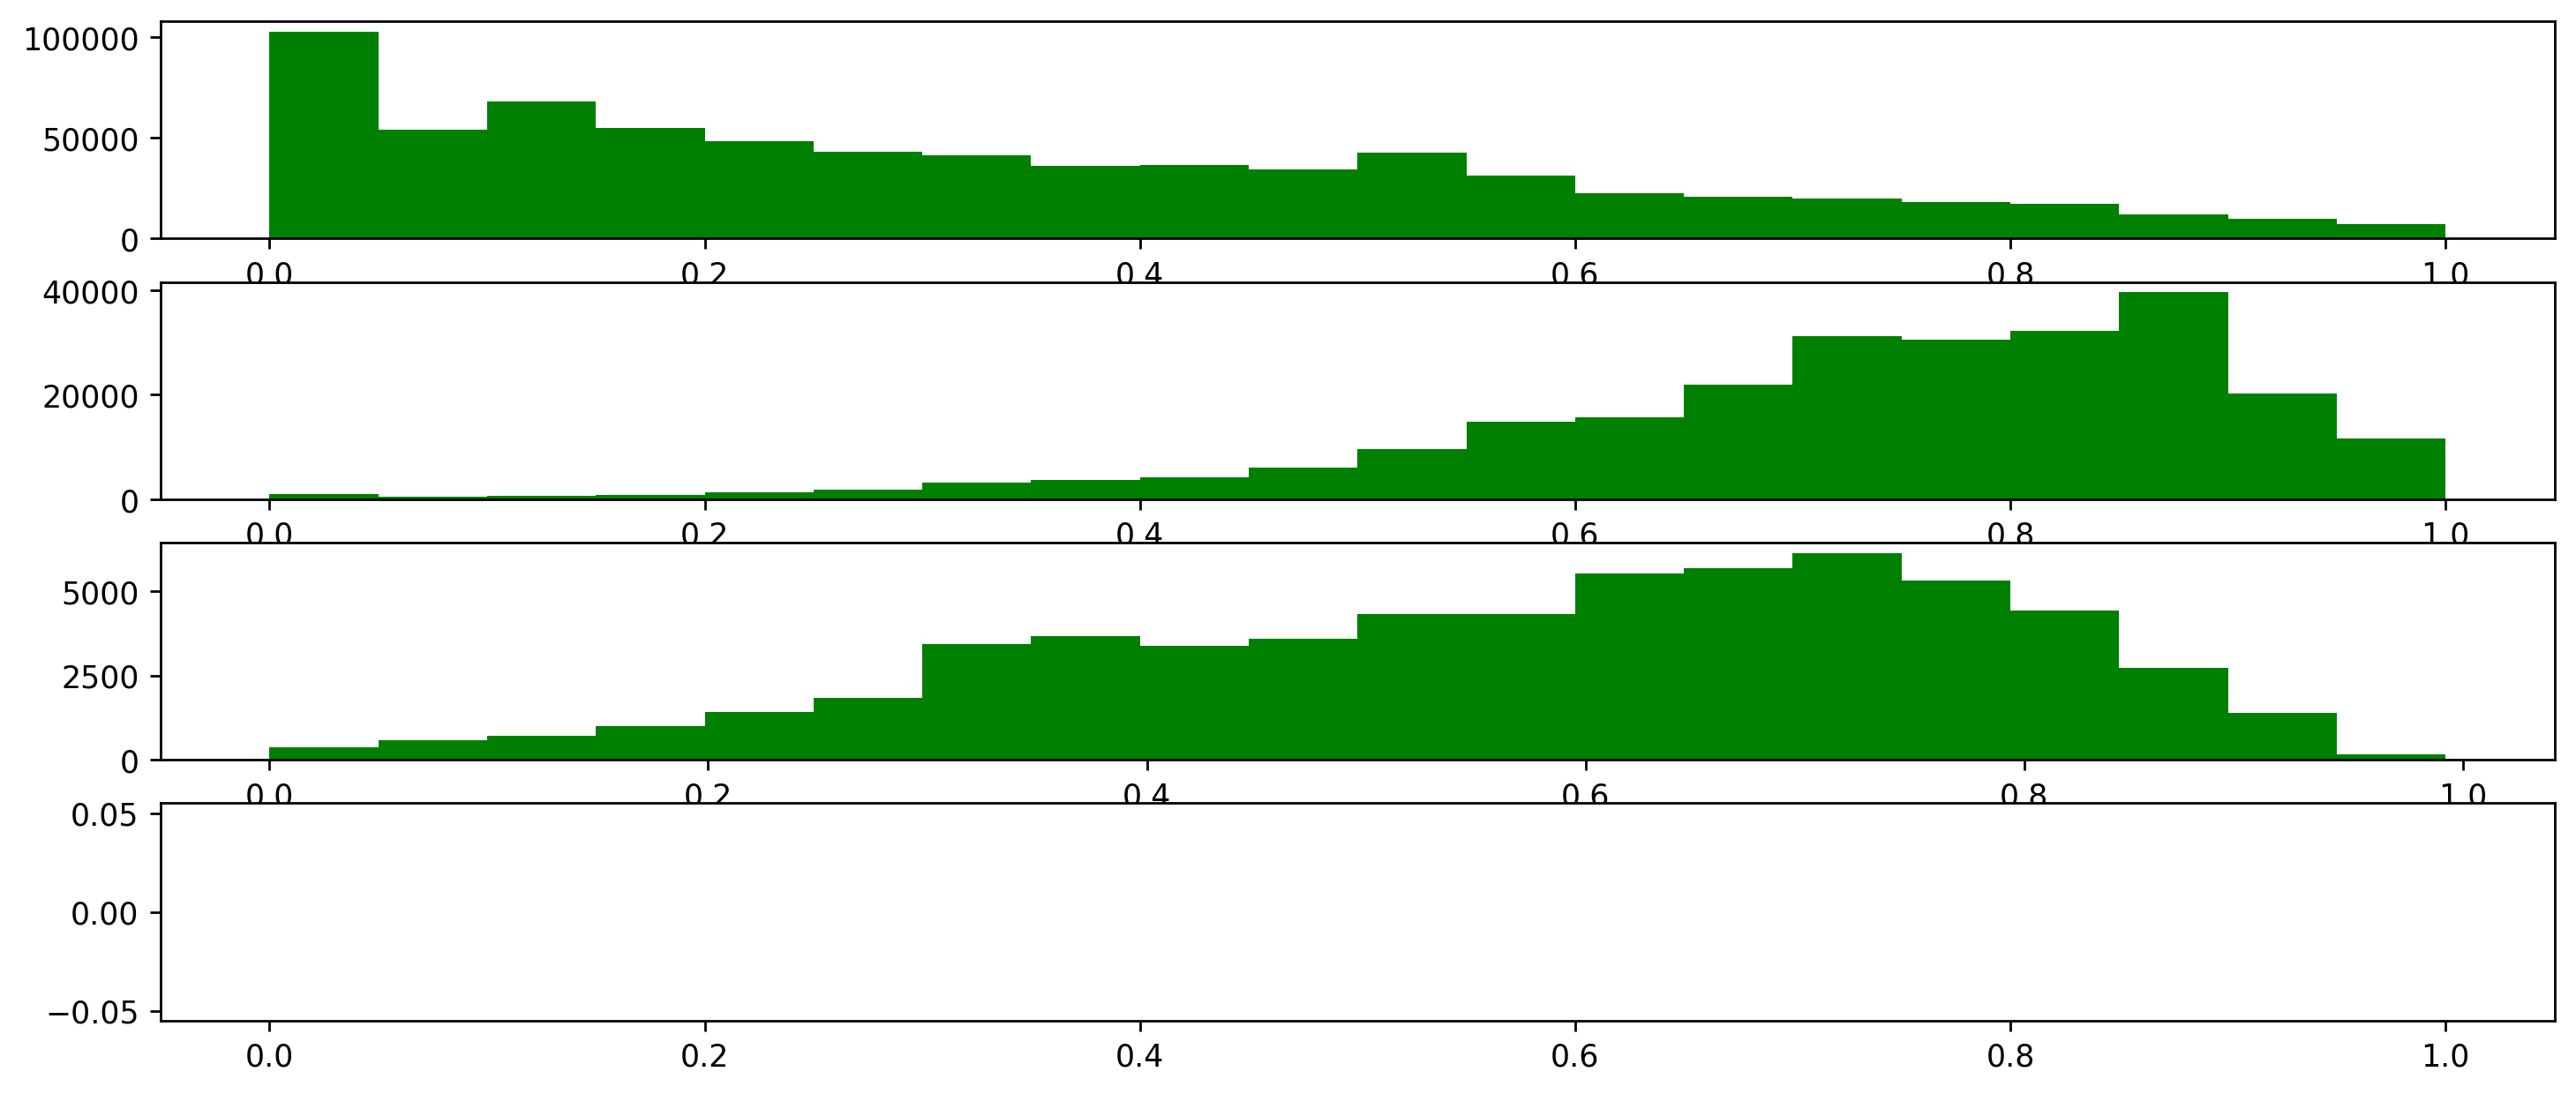

In [60]:
get_colors_dists(1)

### Квантизация изображений

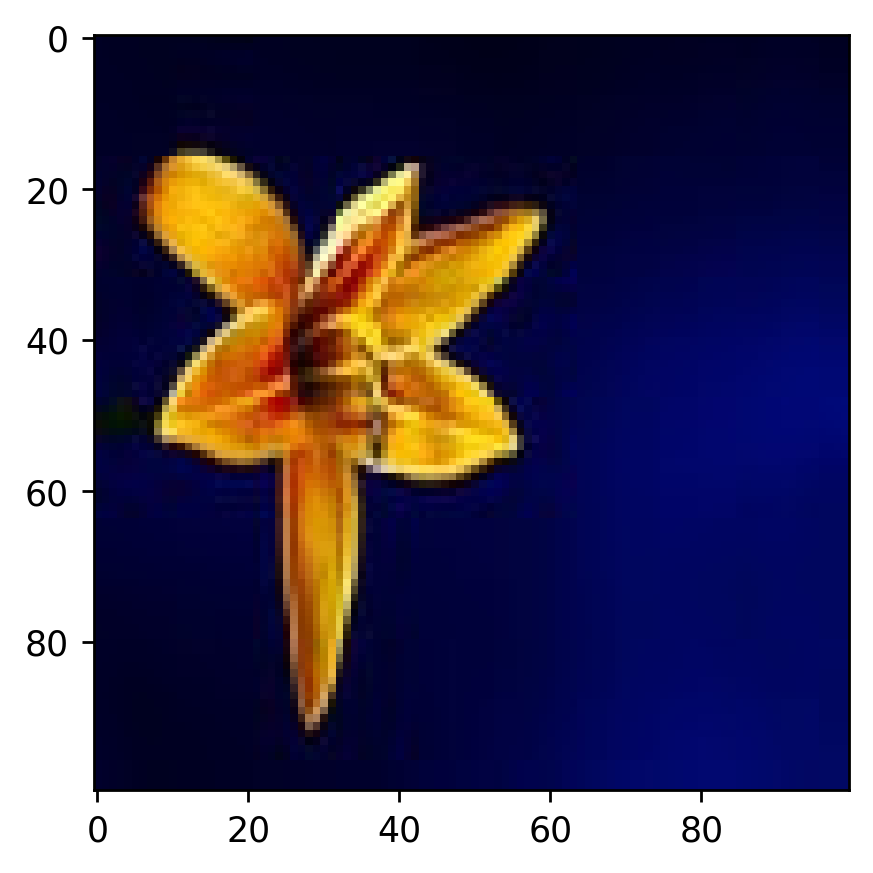

In [61]:
plt.imshow(init_images[50])

In [62]:
def quantize_image(img, n_colors):

    km = KMeans(n_clusters=n_colors)
    img_ = img.reshape((100*100, 3))
    print(img_.shape)
    km.fit(img_)
    labels = km.labels_
    new_colors = km.cluster_centers_
    _, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img)
    ax[1].imshow(np.reshape(new_colors[labels], (100, 100, new_colors.shape[1])))
    plt.show()

(10000, 3)


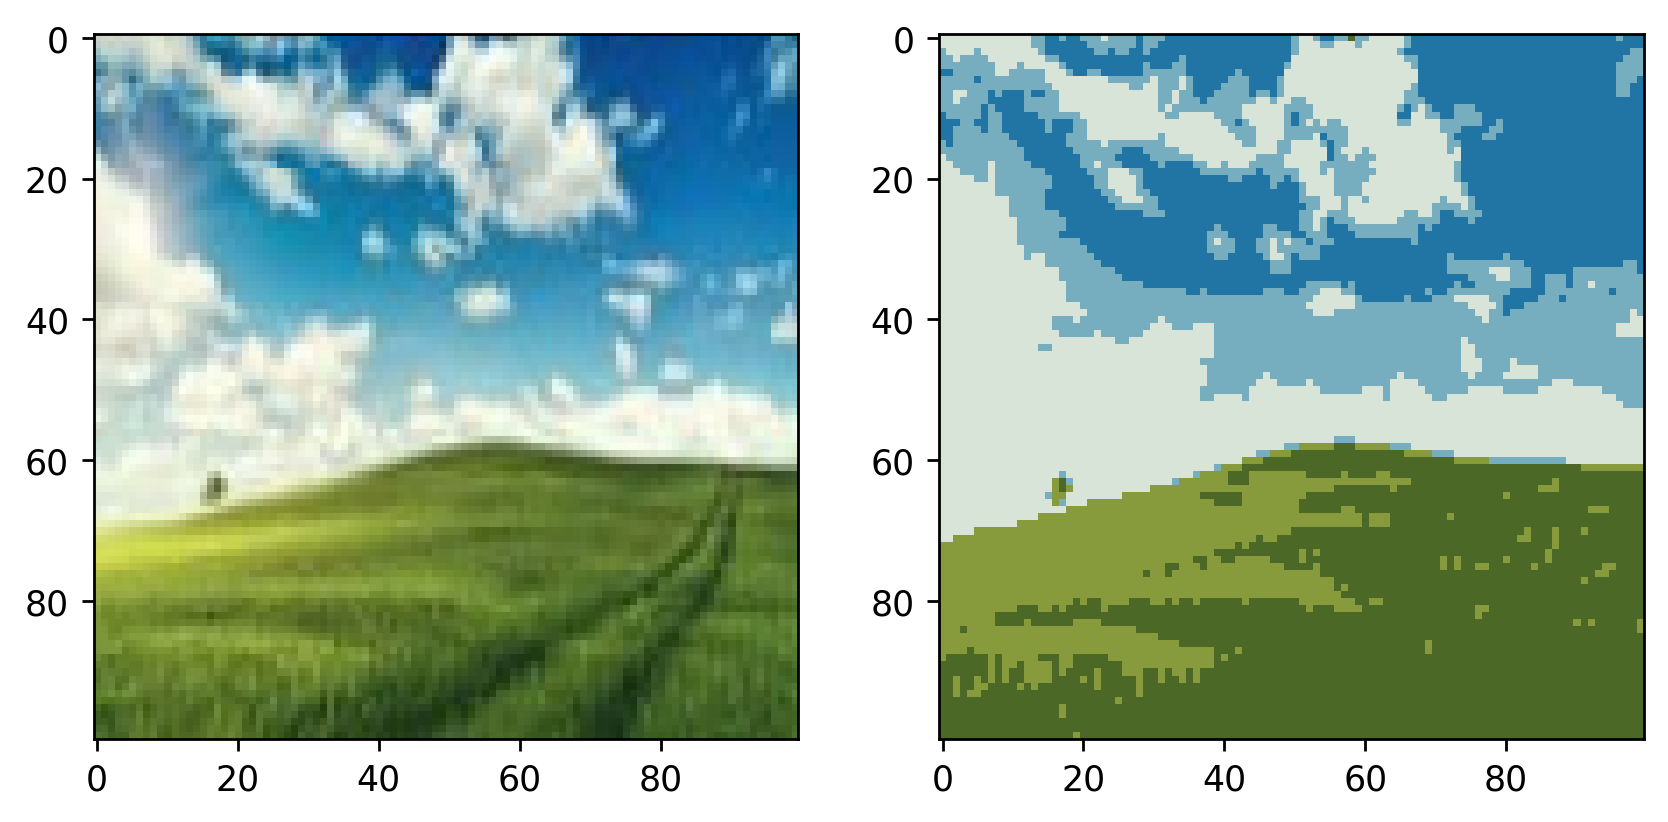

(10000, 3)


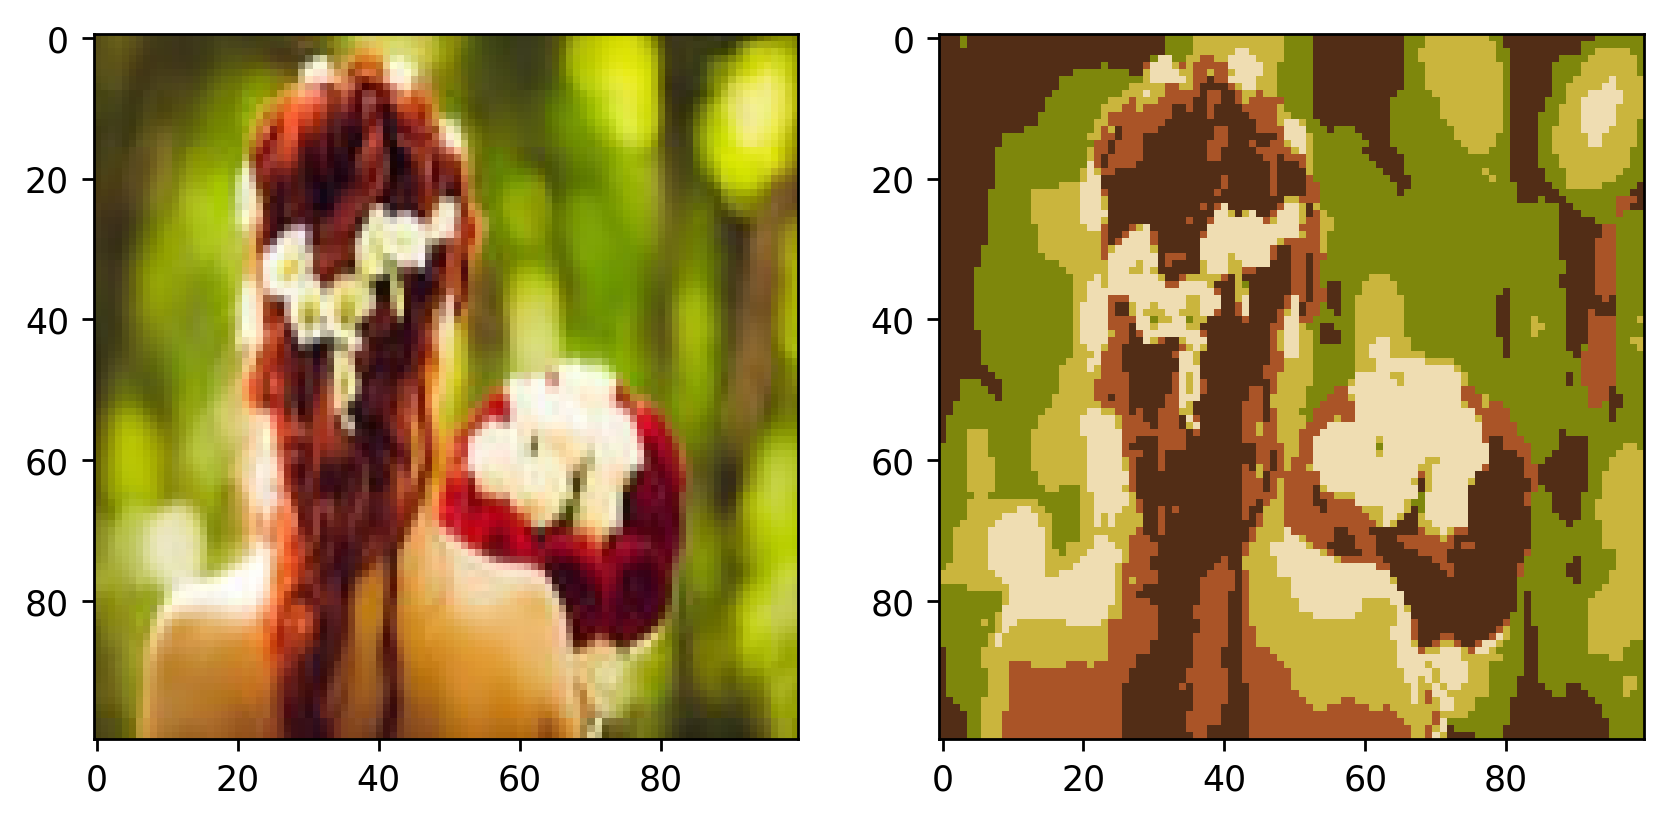

(10000, 3)


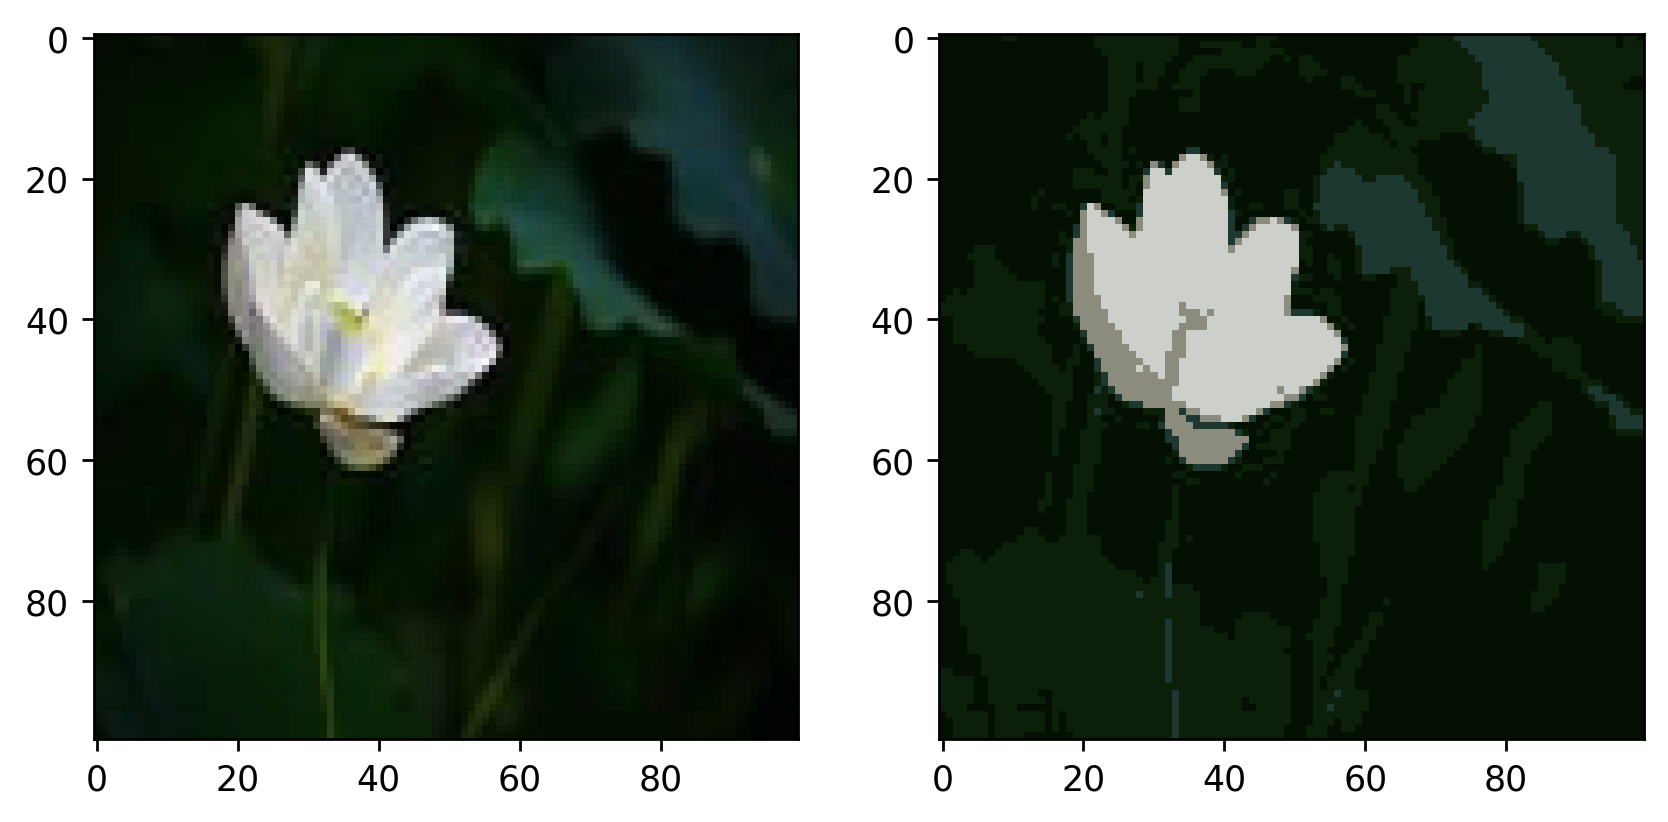

(10000, 3)


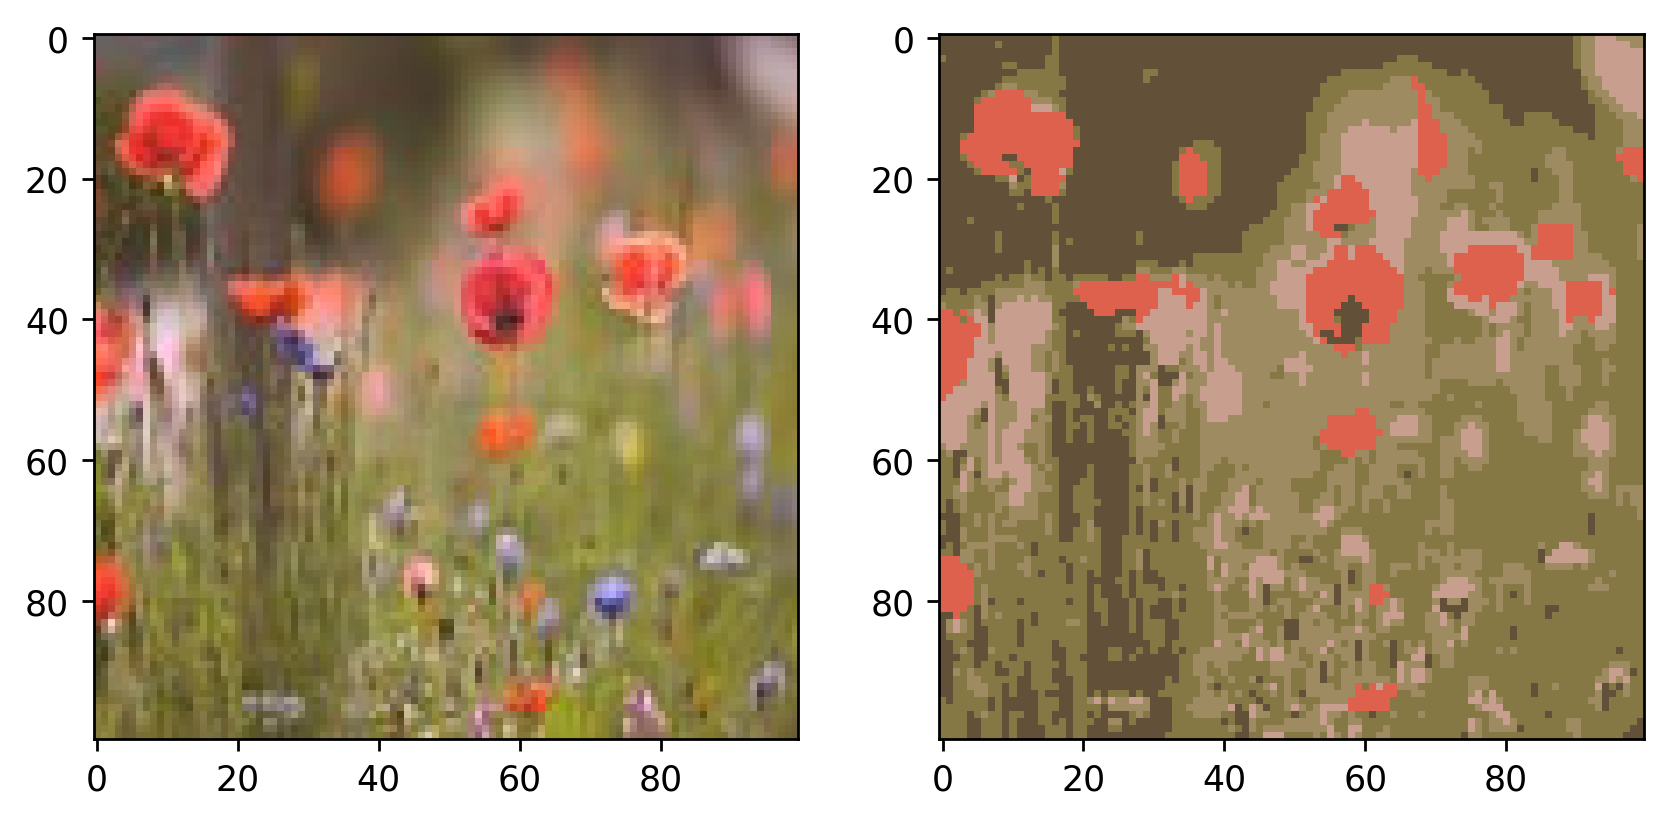

(10000, 3)


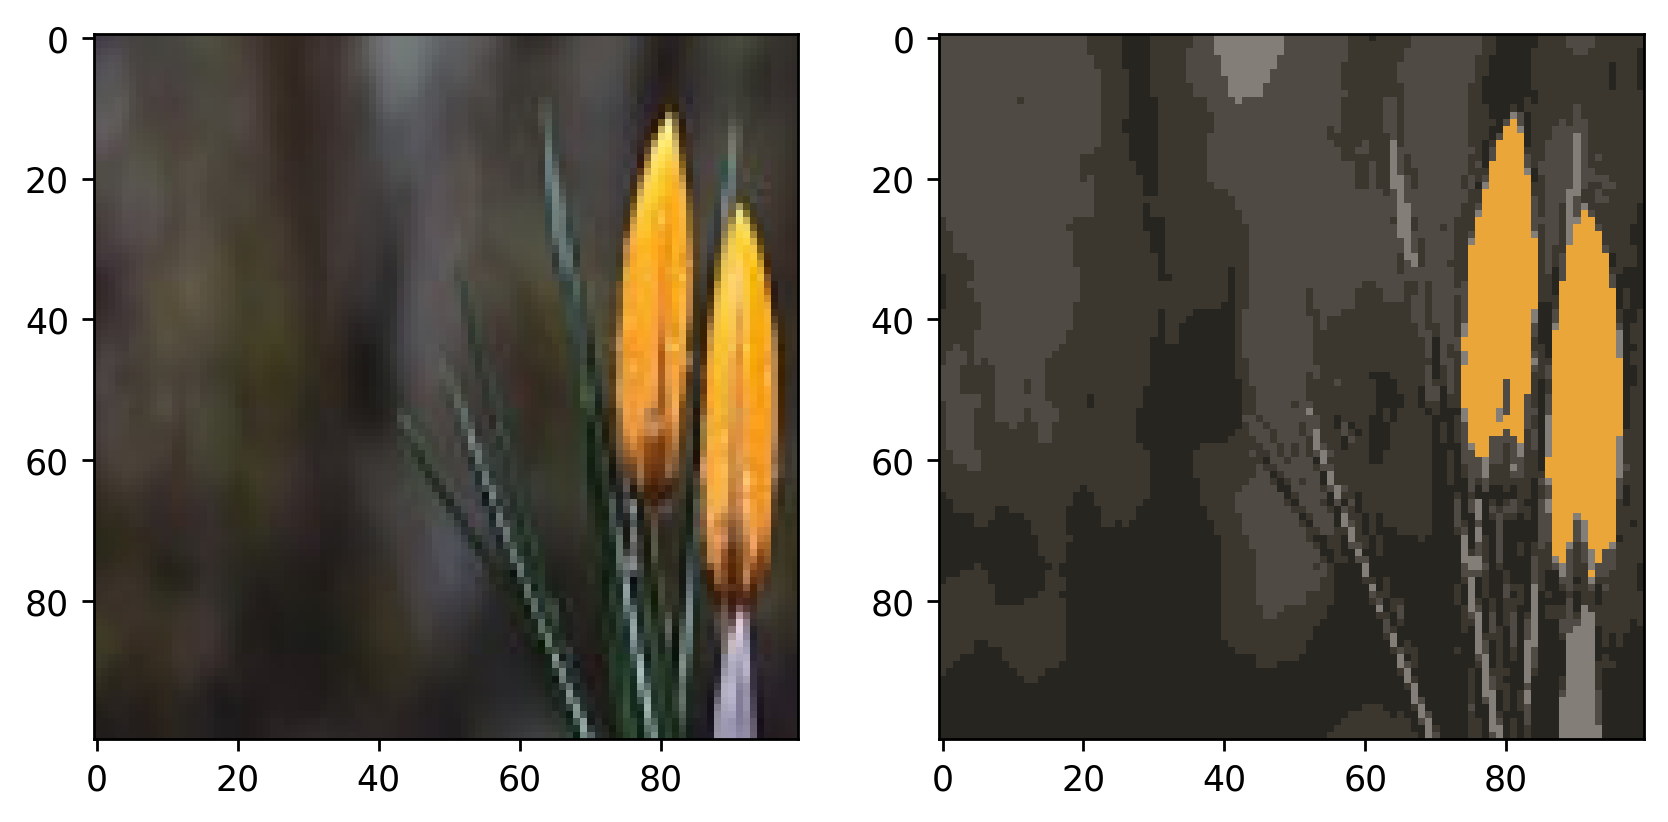

In [63]:
for i in init_images[np.random.randint(1, 103, 5)]:
    quantize_image(i, 5)

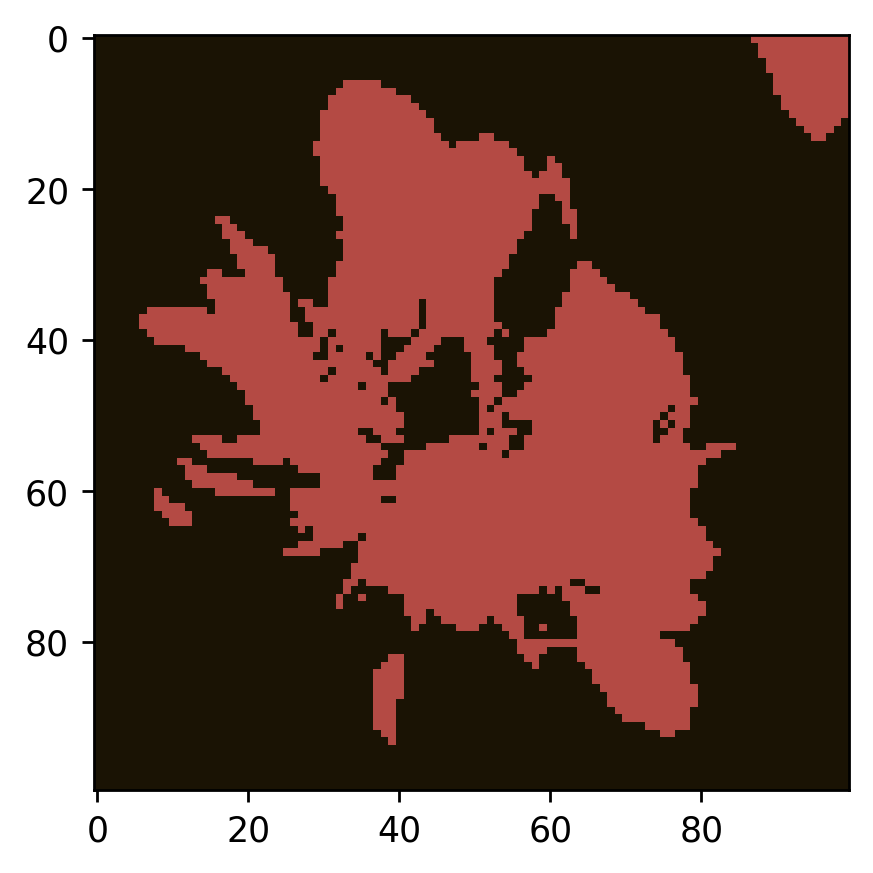

In [64]:
km = KMeans(n_clusters=2)
image = init_images[5].reshape((100 * 100, 3))
km.fit(image)
labels = km.labels_
new_colors = km.cluster_centers_
plt.imshow(np.reshape(new_colors[labels], (100, 100, new_colors.shape[1])))